In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv")
df

,Year,State,Shopping expenditure,Purchase of automotive fuel expenditure,Transportation expenditure,Food & beverage expenditure,Accomodation expenditure,Entrance ticket expenditure,Other expenditure,Visited household expediture,...,Average receipts per trip (RM),Average length of stay (day),Household,Income mean (RM),Income median (RM),Expenditure mean (RM),Expenditure burden (%),Inflation (%),Receipts per visitor (RM),Receipts per household (RM)
0,2018,Johor,1731645,1275235,455811,887832,681081,312497,344688,1037623,...,381,2.54,949100.0,NaN,NaN,NaN,NaN,1.00,498.70,7086.71
1,2019,Johor,2010838,1439192,466143,971456,740566,319504,352689,1109290,...,387,2.54,966000.0,8013.0,6427.0,4793.0,74.58,0.67,519.13,7670.81
2,2020,Johor,1119630,258308,188347,430119,130846,42027,67138,195159,...,307,1.85,1017727.0,7264.0,5690.0,NaN,NaN,-1.46,335.77,2389.64
3,2021,Johor,495151,164824,89338,152467,77690,75139,60462,136779,...,330,2.06,1045400.0,NaN,NaN,NaN,NaN,2.47,342.26,1197.63
4,2022,Johor,1601286,739862,408115,708035,576209,234307,154571,465968,...,377,2.34,1073400.0,8517.0,6879.0,5342.0,77.66,3.42,394.96,4553.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,2021,Terengganu,419566,100429,34569,206405,106273,57983,9205,49682,...,238,2.20,290400.0,NaN,NaN,NaN,NaN,3.44,264.59,3388.43
100,2022,Terengganu,1491085,457090,195005,524112,292024,71732,126640,205609,...,263,2.69,298600.0,7248.0,5878.0,4796.0,81.59,3.05,328.64,11262.56
101,2023,Terengganu,1650481,582975,248973,791250,359323,98603,165869,294844,...,302,2.59,306900.0,NaN,NaN,NaN,NaN,1.80,356.43,13659.17
102,2024,Terengganu,2033824,663228,309689,947370,437078,140166,222002,417004,...,313,2.50,315500.0,7627.0,6627.0,5219.0,78.75,1.50,357.51,16386.69


In [3]:
df.dtypes

Year                                         int64
State                                          str
Shopping expenditure                         int64
Purchase of automotive fuel expenditure      int64
Transportation expenditure                   int64
Food & beverage expenditure                  int64
Accomodation expenditure                     int64
Entrance ticket expenditure                  int64
Other expenditure                            int64
Visited household expediture                 int64
Tourism receipts (RM)                        int64
Domestic visitor                             int64
Tourism trip                                 int64
Average receipts per capita (RM)             int64
Average receipts per trip (RM)               int64
Average length of stay (day)               float64
Household                                  float64
Income mean (RM)                           float64
Income median (RM)                         float64
Expenditure mean (RM)          

In [4]:
df.isnull().sum()

Year                                        0
State                                       0
Shopping expenditure                        0
Purchase of automotive fuel expenditure     0
Transportation expenditure                  0
Food & beverage expenditure                 0
Accomodation expenditure                    0
Entrance ticket expenditure                 0
Other expenditure                           0
Visited household expediture                0
Tourism receipts (RM)                       0
Domestic visitor                            0
Tourism trip                                0
Average receipts per capita (RM)            0
Average receipts per trip (RM)              0
Average length of stay (day)                0
Household                                  13
Income mean (RM)                           52
Income median (RM)                         52
Expenditure mean (RM)                      74
Expenditure burden (%)                     74
Inflation (%)                     

## Initial Trend Visualization

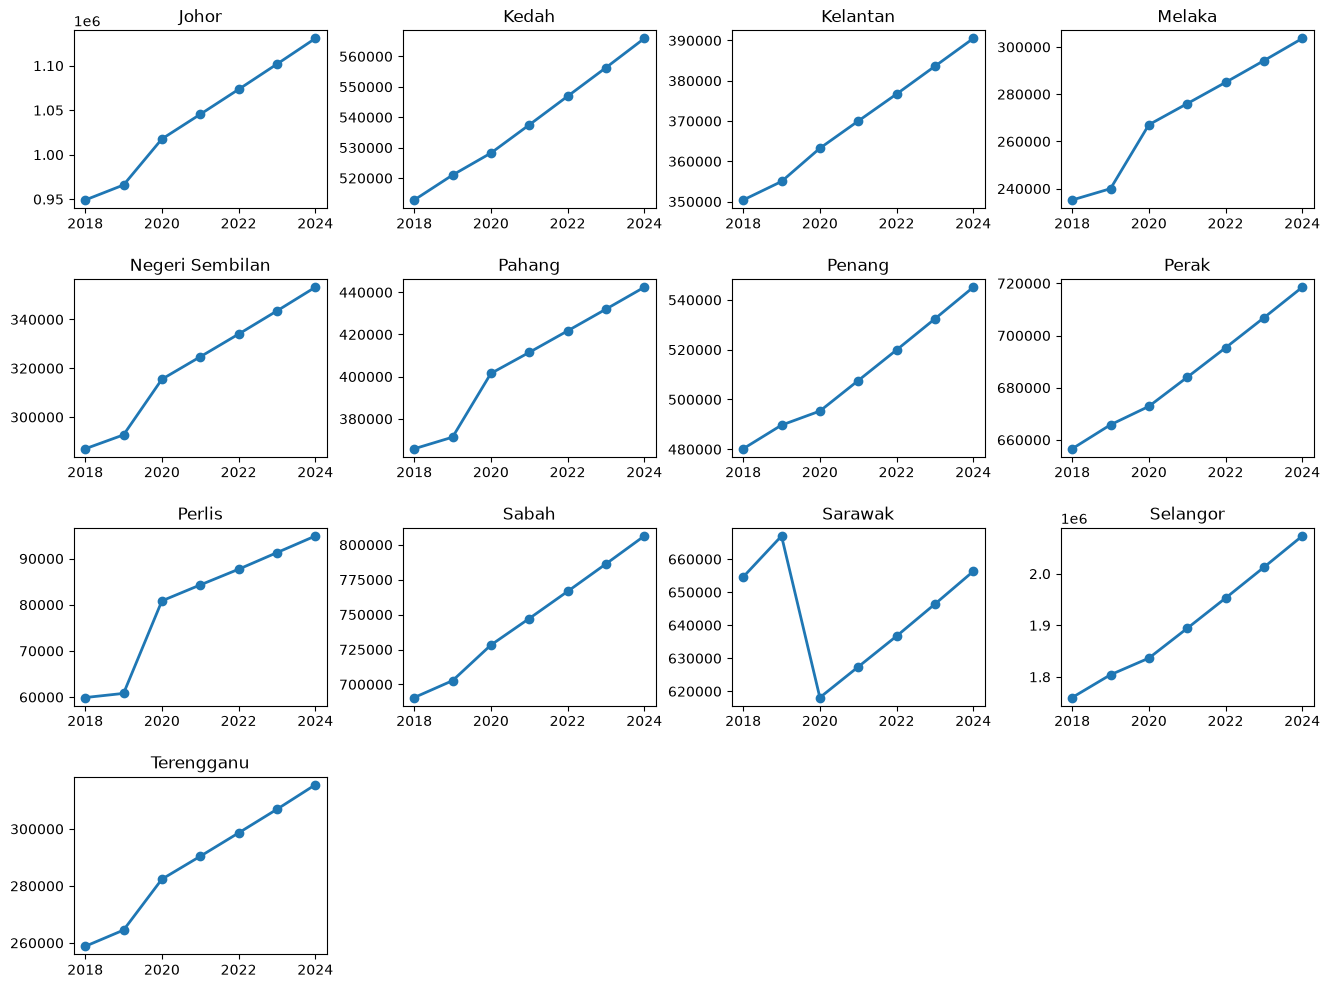

In [5]:
plt.style.use('default')

states = df["State"].unique()

fig = plt.figure(figsize=(16, 12), facecolor='white')

for i in range(len(states)):
    data = df[df["State"] == states[i]].sort_values("Year")

    plt.subplot(4, 4, i+1)
    plt.plot(data["Year"], data["Household"], marker='o', color='tab:blue', linewidth=2)
    plt.title(states[i])
    plt.gca().set_facecolor('white')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

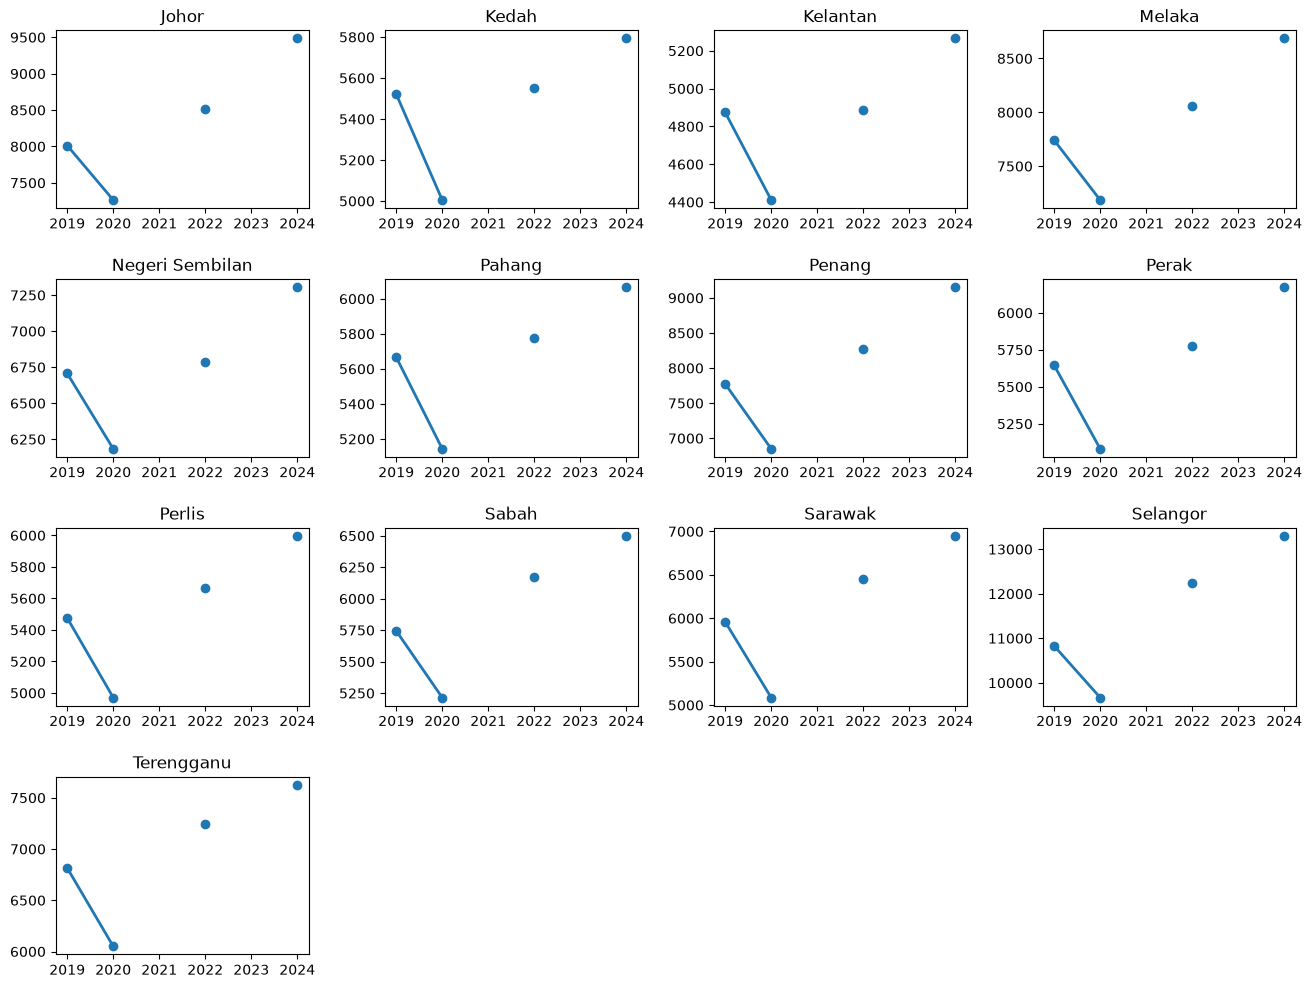

In [6]:
plt.style.use('default')

states = df["State"].unique()

fig = plt.figure(figsize=(16, 12), facecolor='white')

for i in range(len(states)):
    data = df[df["State"] == states[i]].sort_values("Year")

    plt.subplot(4, 4, i+1)
    plt.plot(data["Year"], data["Income mean (RM)"], marker='o', color='tab:blue', linewidth=2)
    plt.title(states[i])
    plt.gca().set_facecolor('white')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

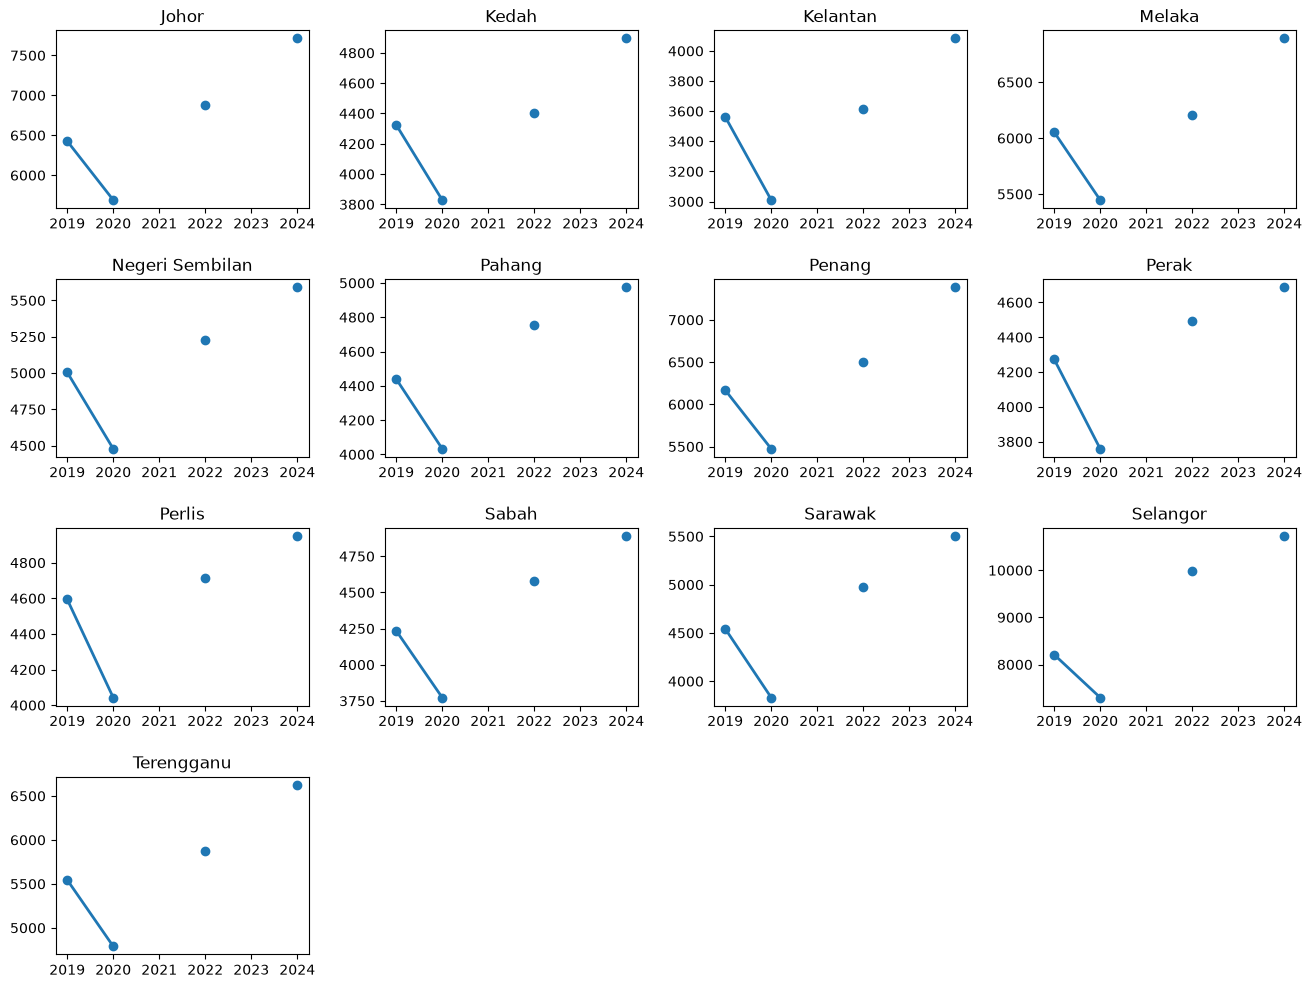

In [7]:
plt.style.use('default')

states = df["State"].unique()

fig = plt.figure(figsize=(16, 12), facecolor='white')

for i in range(len(states)):
    data = df[df["State"] == states[i]].sort_values("Year")

    plt.subplot(4, 4, i+1)
    plt.plot(data["Year"], data["Income median (RM)"], marker='o', color='tab:blue', linewidth=2)
    plt.title(states[i])
    plt.gca().set_facecolor('white')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

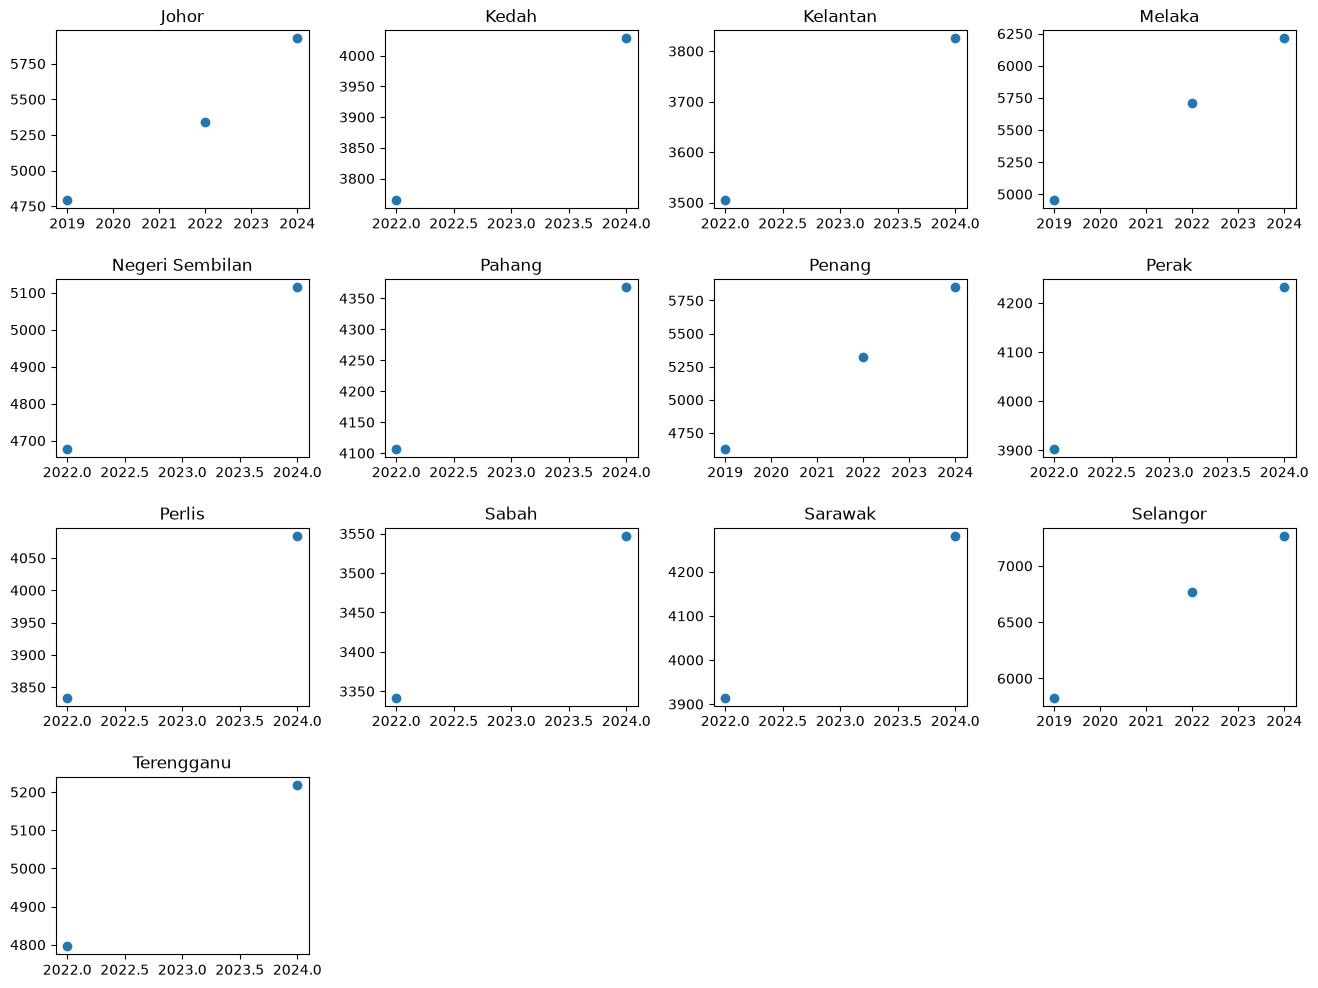

In [8]:
plt.style.use('default')

states = df["State"].unique()

fig = plt.figure(figsize=(16, 12), facecolor='white')

for i in range(len(states)):
    data = df[df["State"] == states[i]].sort_values("Year")

    plt.subplot(4, 4, i+1)
    plt.plot(data["Year"], data["Expenditure mean (RM)"], marker='o', color='tab:blue', linewidth=2)
    plt.title(states[i])
    plt.gca().set_facecolor('white')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

## Interpolation

In [9]:
# Perform true interpolation for year 2023
# Perform extrapolation for year 2025 with trend 2022-2024 (no flat-filling)

from scipy.interpolate import interp1d

cols_to_process = [
    'Household',
    'Income mean (RM)',
    'Income median (RM)',
    'Expenditure mean (RM)'
]

states = df['State'].unique()

processed_dfs = []

for state in states:
    state_df = df[df['State'] == state].sort_values('Year')

    x = state_df['Year'].values

    for col in cols_to_process:
        y = state_df[col].values
        valid_idx = ~np.isnan(y)

        if valid_idx.sum() >= 2:
            f = interp1d(
                x[valid_idx],
                y[valid_idx],
                kind='linear',
                fill_value="extrapolate"
            )
            state_df[col] = f(x)

    processed_dfs.append(state_df)

df = pd.concat(processed_dfs, ignore_index=True)

In [10]:
df.isnull().sum()

Year                                        0
State                                       0
Shopping expenditure                        0
Purchase of automotive fuel expenditure     0
Transportation expenditure                  0
Food & beverage expenditure                 0
Accomodation expenditure                    0
Entrance ticket expenditure                 0
Other expenditure                           0
Visited household expediture                0
Tourism receipts (RM)                       0
Domestic visitor                            0
Tourism trip                                0
Average receipts per capita (RM)            0
Average receipts per trip (RM)              0
Average length of stay (day)                0
Household                                   0
Income mean (RM)                            0
Income median (RM)                          0
Expenditure mean (RM)                       0
Expenditure burden (%)                     74
Inflation (%)                     

## Trend Visualization After Cleaning

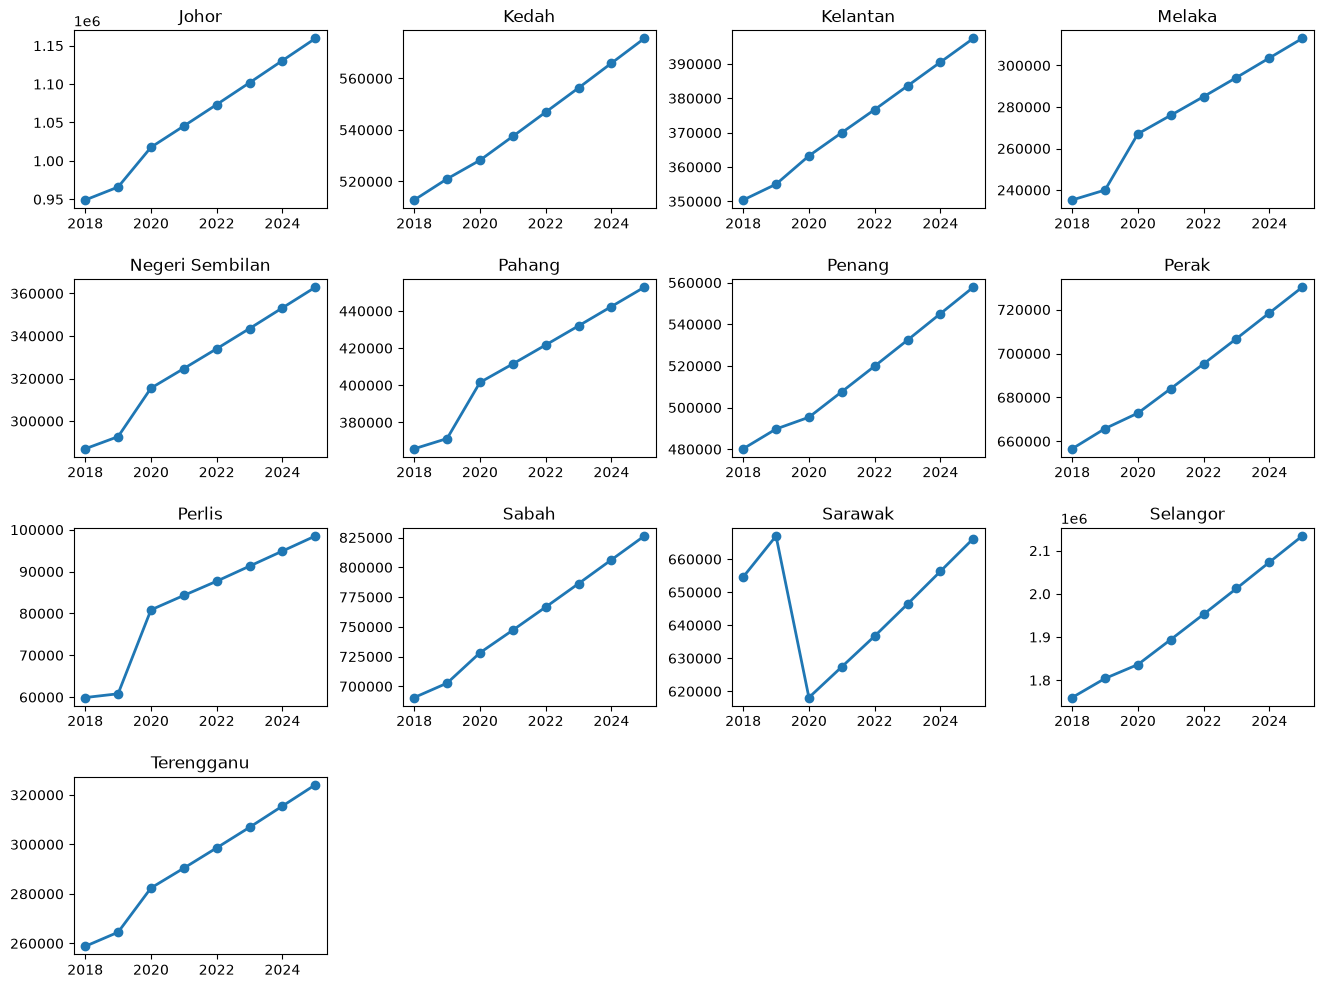

In [11]:
plt.style.use('default')

states = df["State"].unique()

fig = plt.figure(figsize=(16, 12), facecolor='white')

for i in range(len(states)):
    data = df[df["State"] == states[i]].sort_values("Year")

    plt.subplot(4, 4, i+1)
    plt.plot(data["Year"], data["Household"], marker='o', color='tab:blue', linewidth=2)
    plt.title(states[i])
    plt.gca().set_facecolor('white')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

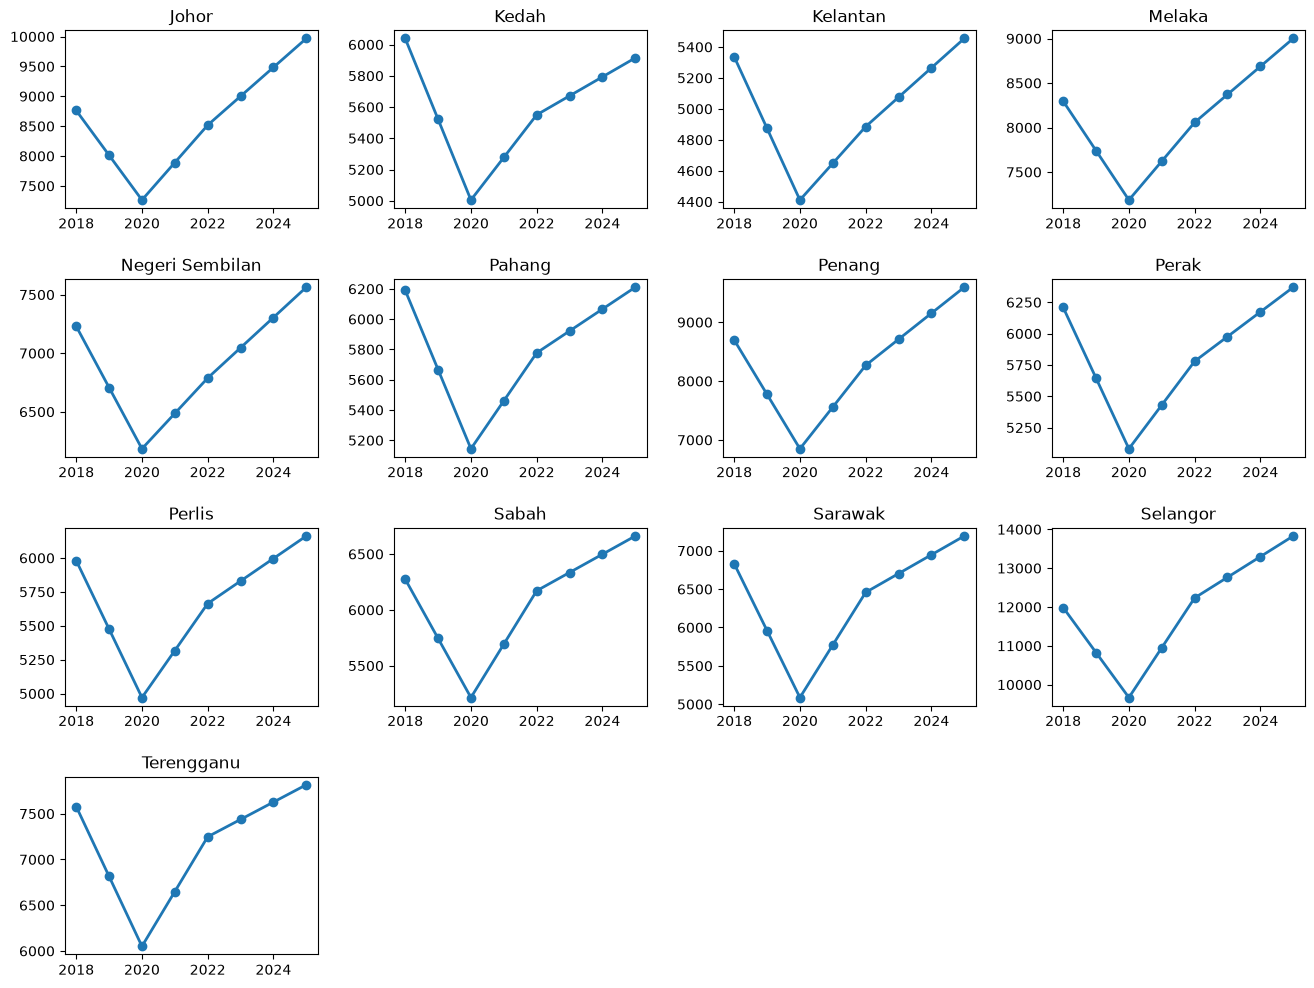

In [12]:
plt.style.use('default')

states = df["State"].unique()

fig = plt.figure(figsize=(16, 12), facecolor='white')

for i in range(len(states)):
    data = df[df["State"] == states[i]].sort_values("Year")

    plt.subplot(4, 4, i+1)
    plt.plot(data["Year"], data["Income mean (RM)"], marker='o', color='tab:blue', linewidth=2)
    plt.title(states[i])
    plt.gca().set_facecolor('white')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

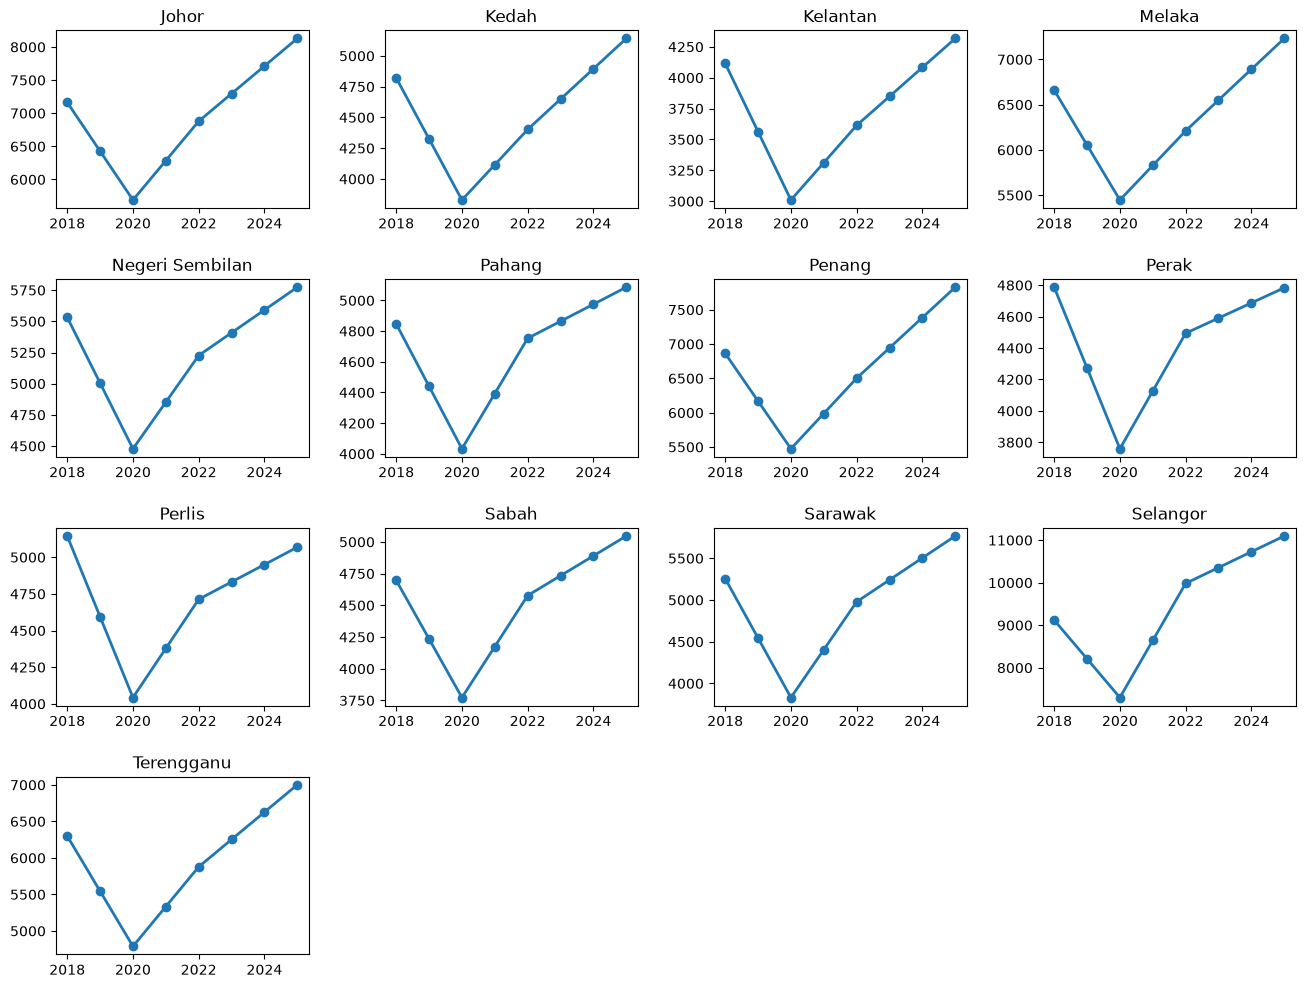

In [13]:
plt.style.use('default')

states = df["State"].unique()

fig = plt.figure(figsize=(16, 12), facecolor='white')

for i in range(len(states)):
    data = df[df["State"] == states[i]].sort_values("Year")

    plt.subplot(4, 4, i+1)
    plt.plot(data["Year"], data["Income median (RM)"], marker='o', color='tab:blue', linewidth=2)
    plt.title(states[i])
    plt.gca().set_facecolor('white')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

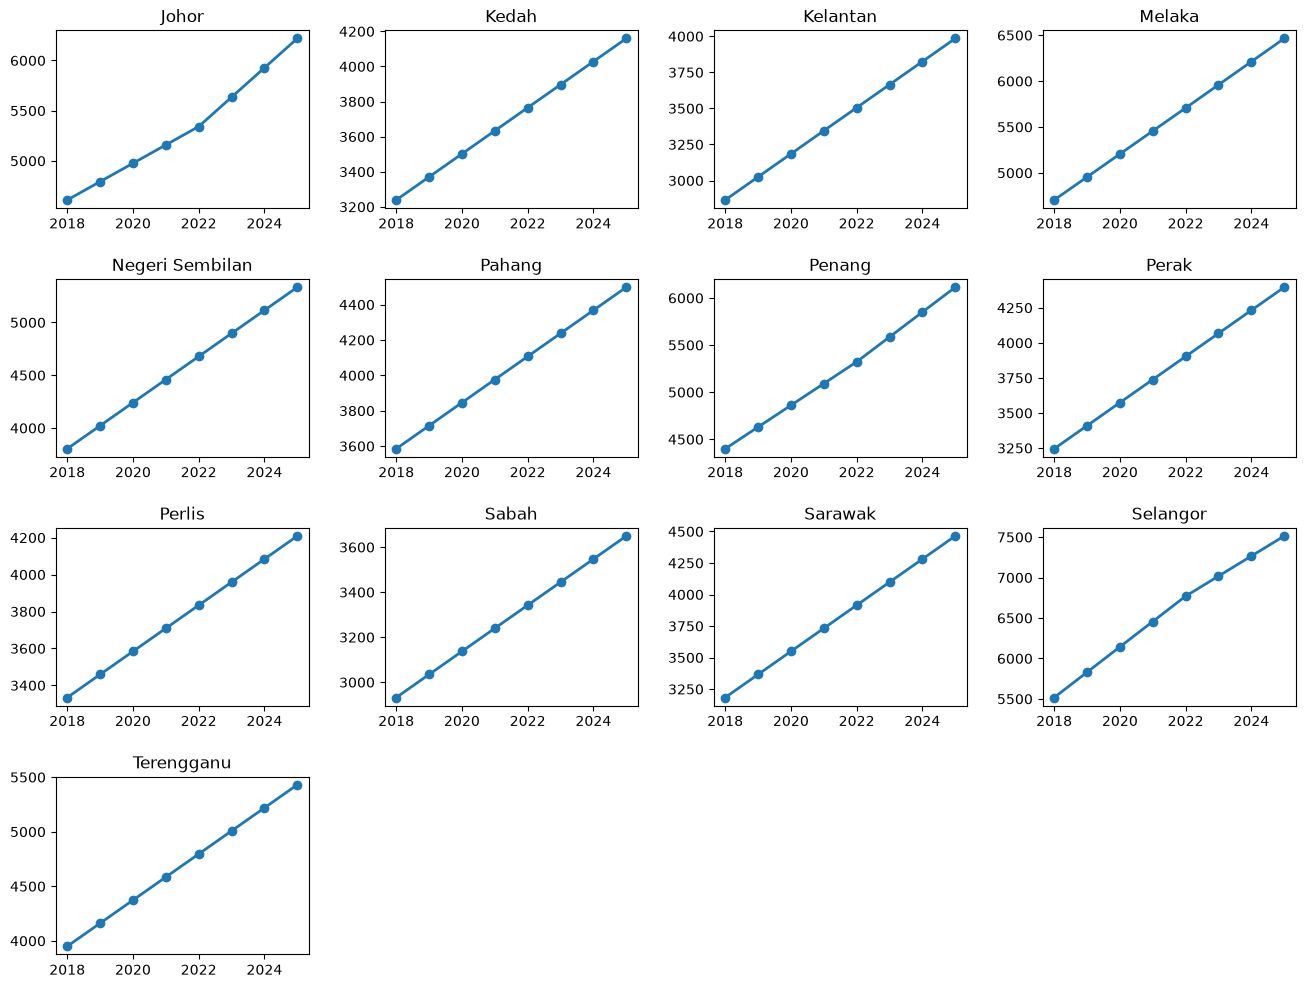

In [14]:
plt.style.use('default')

states = df["State"].unique()

fig = plt.figure(figsize=(16, 12), facecolor='white')

for i in range(len(states)):
    data = df[df["State"] == states[i]].sort_values("Year")

    plt.subplot(4, 4, i+1)
    plt.plot(data["Year"], data["Expenditure mean (RM)"], marker='o', color='tab:blue', linewidth=2)
    plt.title(states[i])
    plt.gca().set_facecolor('white')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

In [15]:
df["Expenditure burden (%)"] = round(df["Expenditure mean (RM)"] / df["Income median (RM)"] * 100, 2)
df["Receipts per household (RM)"] = round(df["Tourism receipts (RM)"] / df["Household"], 2)

In [16]:
df.isnull().sum()

Year                                       0
State                                      0
Shopping expenditure                       0
Purchase of automotive fuel expenditure    0
Transportation expenditure                 0
Food & beverage expenditure                0
Accomodation expenditure                   0
Entrance ticket expenditure                0
Other expenditure                          0
Visited household expediture               0
Tourism receipts (RM)                      0
Domestic visitor                           0
Tourism trip                               0
Average receipts per capita (RM)           0
Average receipts per trip (RM)             0
Average length of stay (day)               0
Household                                  0
Income mean (RM)                           0
Income median (RM)                         0
Expenditure mean (RM)                      0
Expenditure burden (%)                     0
Inflation (%)                              0
Receipts p

In [17]:
df.to_excel("cleaned_data 2018-2025.xlsx", index=False)